# Phase 2 — Data Cleaning
## Predicting Diabetes Risk Using Machine Learning

---

### Context

**Input:** `../data/raw/brfss_2022_2024_combined.csv`  
→ 1,336,125 rows × 23 columns produced by `00_data_collection.ipynb`

**Output:** `../data/processed/brfss_cleaned.csv`  
→ Analysis-ready dataset with a binary target, recoded special codes, dropped uninformative columns, and imputed missing values.

---

### What This Notebook Does

This notebook implements every cleaning decision documented in **Phase 1 (Data Understanding)** and recorded in `ProjectDriven.md`, including corrections identified from Phase 2 execution results.

The cleaning pipeline runs in the following order:

| Step | Section | Action |
|------|---------|--------|
| 1 | Load | Read raw combined CSV |
| 2 | Drop columns | Remove 5 structurally uninformative / duplicate columns |
| 3 | Recode special codes | 88→0 for days-count vars; 7/9/77/99→NaN for all others |
| 4 | Binarise target | `DIABETE4` → `DIABETES` (binary 0/1) |
| 5 | Drop `_RACE` | Structurally absent in 2022; imputation would introduce demographic bias |
| 6 | Impute missing values | Median / mode for high-missing vars; row-drop for <3% missing only |
| 7 | Final validation | Confirm zero NaN, expected shape, class distribution |
| 8 | Save | Write `brfss_cleaned.csv` to `data/processed/` |

---

### Design Note — Revised Imputation Scope

Phase 1 EDA reported missing rates **before** recoding special codes (7/9/77/99).  
After recoding, the **effective missing rates** for several variables were substantially higher:

| Variable | Phase 1 raw missing | Post-recode missing | Action revised |
|----------|--------------------|--------------------|----------------|
| `_AGEG5YR` | 0.0% | **16.9%** | Median impute (was: no action needed) |
| `_SMOKER3` | 0.0% | **6.8%** | Median impute (was: no action needed) |
| `PHYSHLTH` | ~0% | **4.5%** | Median impute (was: row-drop at <3%) |
| `MENTHLTH` | ~0% | **3.7%** | Median impute (was: row-drop at <3%) |

Applying row-drop to these variables would have removed **~390k rows (30%)** — an unacceptable data loss,  
particularly for `_AGEG5YR`, which is the **3rd-ranked predictor** (Pearson r = 0.231 with diabetes).  
These four variables are moved to the median-imputation group.

In [1]:
# ── Standard imports ─────────────────────────────────────────────────────────
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Plotting style ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ── Paths (pathlib — cross-platform: Windows / Mac / Linux) ──────────────────
ROOT        = Path("../")
RAW_DIR     = ROOT / "data" / "raw"
PROC_DIR    = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "outputs" / "figures"

PROC_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RAW_FILE   = RAW_DIR  / "brfss_2022_2024_combined.csv"
CLEAN_FILE = PROC_DIR / "brfss_cleaned.csv"

print(f"Raw file  : {RAW_FILE}")
print(f"Output    : {CLEAN_FILE}")

Raw file  : ..\data\raw\brfss_2022_2024_combined.csv
Output    : ..\data\processed\brfss_cleaned.csv


---
## Section 1 — Load Raw Data

We load the combined 3-year BRFSS dataset assembled in Phase 0.  
The file contains all 23 columns extracted from the CDC fixed-width ASCII files for 2022, 2023, and 2024.

**Important:** At this point, BRFSS special codes (7, 9, 77, 88, 99) are still present as numeric values.  
They will be recoded in Section 3. Until then, missing-rate figures reflect only structural NaN  
(variables entirely absent from a given year), **not** the true effective missing rate  
that will emerge after special codes are masked.

In [2]:
df = pd.read_csv(RAW_FILE, low_memory=False)

print(f"Shape    : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn dtypes:")
print(df.dtypes.to_string())

Shape    : 1,336,125 rows × 23 columns

Column dtypes:
YEAR          int64
DIABETE4    float64
PREDIAB2    float64
GENHLTH     float64
PHYSHLTH    float64
MENTHLTH    float64
POORHLTH    float64
CHECKUP1    float64
EXERANY2    float64
DIFFWALK    float64
BPHIGH6     float64
CVDINFR4    float64
CVDSTRK3    float64
SEXVAR        int64
EDUCA       float64
INCOME3     float64
_STATE        int64
_SEX          int64
_RACE       float64
_AGEG5YR      int64
_BMI5CAT    float64
_SMOKER3      int64
_CHOLCH3    float64


In [3]:
print("First 5 rows:")
df.head()

First 5 rows:


,YEAR,DIABETE4,PREDIAB2,GENHLTH,PHYSHLTH,MENTHLTH,POORHLTH,CHECKUP1,EXERANY2,DIFFWALK,...,SEXVAR,EDUCA,INCOME3,_STATE,_SEX,_RACE,_AGEG5YR,_BMI5CAT,_SMOKER3,_CHOLCH3
0,2022,1.0,NaN,2.0,88.0,88.0,NaN,1.0,2.0,2.0,...,2,6.0,99.0,1,2,NaN,13,NaN,4,NaN
1,2022,3.0,NaN,1.0,88.0,88.0,NaN,8.0,2.0,2.0,...,2,4.0,5.0,1,2,NaN,13,3.0,4,NaN
2,2022,3.0,NaN,2.0,2.0,3.0,2.0,1.0,1.0,2.0,...,2,6.0,10.0,1,2,NaN,8,3.0,4,NaN
3,2022,3.0,NaN,1.0,88.0,88.0,NaN,1.0,1.0,2.0,...,2,4.0,77.0,1,2,NaN,14,2.0,2,NaN
4,2022,3.0,NaN,4.0,2.0,88.0,88.0,1.0,1.0,2.0,...,2,5.0,5.0,1,2,NaN,5,2.0,4,NaN


In [4]:
# ── Raw missing value overview ────────────────────────────────────────────────
# These counts reflect only structural NaN (variables absent from certain years),
# NOT special codes 7/9/77/88/99 which are still stored as numeric values.
# The true effective missing rate is revealed in Section 3 after recoding.
missing_raw     = df.isnull().sum()
missing_raw_pct = (missing_raw / len(df) * 100).round(1)
summary = pd.DataFrame({"missing_n": missing_raw, "missing_%": missing_raw_pct})

print("Raw missing value counts (pre-recode — special codes still numeric):")
summary.sort_values("missing_%", ascending=False)

Raw missing value counts (pre-recode — special codes still numeric):


,missing_n,missing_%
_CHOLCH3,902802,67.6
BPHIGH6,902805,67.6
PREDIAB2,870556,65.2
POORHLTH,559960,41.9
_RACE,445218,33.3
_BMI5CAT,132378,9.9
DIFFWALK,56973,4.3
INCOME3,30276,2.3
EDUCA,21,0.0
_SMOKER3,0,0.0


---
## Section 2 — Drop Columns

Five columns are removed before any further processing.  
Each drop is grounded in Phase 1 findings:

| Column | Raw missing | Reason for removal |
|--------|------------|--------------------|
| `BPHIGH6` | 67.6% | **Present in 2023 only.** Two-thirds of records have no value across the combined dataset. Cannot be reliably imputed across year boundaries. |
| `_CHOLCH3` | 67.6% | **Same structural problem as `BPHIGH6`.** 2023-only variable with 67.6% missing. |
| `PREDIAB2` | 65.2% | **Target leakage risk** — directly encodes borderline diabetes status, which would inflate model performance artificially. High missing rate (65.2%) makes it unusable regardless. |
| `SEXVAR` | 0.0% | **Perfect duplicate of `_SEX`** (Pearson r = 1.00). Identical variable collected in parallel. Retaining both introduces perfect multicollinearity with zero information gain. |
| `_STATE` | 0.0% | **50-level FIPS categorical code** with no continuous or ordinal meaning. One-hot encoding would add 49 near-sparse columns. Regional effects can be reintroduced via aggregated features in Phase 3 if warranted. |

In [5]:
COLS_TO_DROP = ["BPHIGH6", "_CHOLCH3", "PREDIAB2", "SEXVAR", "_STATE"]

shape_before = df.shape
df = df.drop(columns=COLS_TO_DROP)
shape_after = df.shape

print(f"Shape before : {shape_before[0]:,} rows × {shape_before[1]} columns")
print(f"Shape after  : {shape_after[0]:,} rows × {shape_after[1]} columns")
print()
print(f"Columns dropped ({len(COLS_TO_DROP)}): {COLS_TO_DROP}")
print()
print(f"Remaining columns ({len(df.columns)}):")
print(list(df.columns))

Shape before : 1,336,125 rows × 23 columns
Shape after  : 1,336,125 rows × 18 columns

Columns dropped (5): ['BPHIGH6', '_CHOLCH3', 'PREDIAB2', 'SEXVAR', '_STATE']

Remaining columns (18):
['YEAR', 'DIABETE4', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'CHECKUP1', 'EXERANY2', 'DIFFWALK', 'CVDINFR4', 'CVDSTRK3', 'EDUCA', 'INCOME3', '_SEX', '_RACE', '_AGEG5YR', '_BMI5CAT', '_SMOKER3']


---
## Section 3 — Recode Special Codes

The BRFSS survey uses a standardised set of special and non-response codes that must be correctly  
interpreted before any analysis or modelling. Two distinct treatments apply:

---

### Code 88 → 0 (days-count variables only: `PHYSHLTH`, `MENTHLTH`, `POORHLTH`)

These questions ask: *"How many days in the past 30 days was your [health dimension] not good?"*  
Code **88 = "None / zero days"** is a **valid, meaningful measurement** — it indicates the respondent  
experienced zero days of poor health. This is the healthiest possible response, not a non-response.

Converting 88 to NaN and then imputing would:
- Artificially inflate mean poor-health day counts
- Introduce systematic bias by treating healthy respondents as missing
- Destroy the true zero-inflated distribution of these variables

→ **Recode 88 → 0** (applies only to these three variables)

---

### Codes 7 / 77 / 9 / 99 → NaN (all remaining variables)

| Code | Meaning | Interpretation |
|------|---------|----------------|
| 7 / 77 | Don't know / Not sure | Respondent could not provide a value |
| 9 / 99 | Refused | Respondent actively declined to answer |

These are genuine non-responses with no numeric meaning.  
Treating them as face values (e.g., 9 on a 1–5 health scale) would corrupt distributions  
and generate spurious model signals.  
→ **Recode all to NaN** — to be handled by imputation or row-drop in Section 6

---

### ⚠️ Post-recode missing rates will be much higher than raw NaN counts

Variables such as `_AGEG5YR` (code 9 = "Refused age") and `INCOME3` (code 77/99 = "Don't know/Refused income")  
have near-zero raw NaN but high proportions of 9/77/99 responses.  
The imputation strategy in Section 6 is determined by **post-recode effective missing rates**.

In [6]:
# ── 3a. Code 88 → 0 for days-count variables only ────────────────────────────
DAYS_VARS = ["PHYSHLTH", "MENTHLTH", "POORHLTH"]

print("Code 88 → 0 recoding (days-count variables only):")
print(f"  {'Variable':<12} {'NaN before':>12} {'NaN after':>10} {'88s recoded':>13}")
print("  " + "-" * 52)

for col in DAYS_VARS:
    nan_before = df[col].isnull().sum()
    count_88   = (df[col] == 88).sum()
    df[col]    = df[col].replace(88, 0)
    nan_after  = df[col].isnull().sum()
    print(f"  {col:<12} {nan_before:>12,} {nan_after:>10,} {count_88:>13,}")

print()
print("→ ~790k 'zero days' responses recovered per variable.")
print("  These are valid health measurements, not missing data.")

Code 88 → 0 recoding (days-count variables only):
  Variable       NaN before  NaN after   88s recoded
  ----------------------------------------------------
  PHYSHLTH               13         13       791,960
  MENTHLTH                9          9       792,164
  POORHLTH          559,960    559,960       394,921

→ ~790k 'zero days' responses recovered per variable.
  These are valid health measurements, not missing data.


In [7]:
# ── 3b. Codes 7, 9, 77, 99 → NaN for all remaining variables ─────────────────
# Applied across all feature columns (excluding YEAR, which uses no special codes).
SPECIAL_CODES = [7, 9, 77, 99]

print("Codes 7 / 9 / 77 / 99 → NaN recoding:")
print(f"  {'Variable':<12} {'NaN before':>12} {'NaN after':>10} {'Recoded':>10}")
print("  " + "-" * 49)

# Exclude YEAR from recoding — it stores the survey year (2022/2023/2024), not a BRFSS response code
feature_cols = [c for c in df.columns if c != "YEAR"]

for col in feature_cols:
    nan_before = df[col].isnull().sum()
    mask       = df[col].isin(SPECIAL_CODES)
    n_recoded  = mask.sum()
    df.loc[mask, col] = np.nan
    nan_after  = df[col].isnull().sum()
    if n_recoded > 0 or nan_before > 0:
        print(f"  {col:<12} {nan_before:>12,} {nan_after:>10,} {n_recoded:>10,}")

print()
print("→ Recoding complete.")
print("  Key observations:")
print("  • _AGEG5YR: ~226k recoded  — code 9 ('Refused age') is common")
print("  • INCOME3 : ~576k recoded  — codes 77/99 ('Refused income') are very common")
print("  These will be handled by median imputation in Section 6.")

Codes 7 / 9 / 77 / 99 → NaN recoding:
  Variable       NaN before  NaN after    Recoded
  -------------------------------------------------
  DIABETE4               12      3,105      3,093
  GENHLTH                12      3,770      3,758
  PHYSHLTH               13     61,417     61,404
  MENTHLTH                9     50,073     50,064
  POORHLTH          559,960    597,207     37,247
  CHECKUP1                7     16,914     16,907
  EXERANY2                7      3,659      3,652
  DIFFWALK           56,973     62,314      5,341
  CVDINFR4                9      8,748      8,739
  CVDSTRK3                9      4,483      4,474
  EDUCA                  21      7,071      7,050
  INCOME3            30,276    606,238    575,962
  _RACE             445,218    484,416     39,198
  _AGEG5YR                0    226,505    226,505
  _BMI5CAT          132,378    132,378          0
  _SMOKER3                0     90,546     90,546

→ Recoding complete.
  Key observations:
  • _AGEG5YR: ~226

In [8]:
# ── 3c. Post-recode effective missing rate summary ────────────────────────────
# This is the TRUE effective missing rate and the basis for all imputation decisions.
# Compare these numbers to the raw NaN counts in Section 1 to see the impact of recoding.
post_recode_missing     = df.isnull().sum()
post_recode_pct         = (post_recode_missing / len(df) * 100).round(1)
pr_df = pd.DataFrame({"missing_n": post_recode_missing, "missing_%": post_recode_pct})

print("Post-recode effective missing rates (basis for Section 6 imputation decisions):")
pr_df[pr_df["missing_n"] > 0].sort_values("missing_%", ascending=False)

Post-recode effective missing rates (basis for Section 6 imputation decisions):


,missing_n,missing_%
INCOME3,606238,45.4
POORHLTH,597207,44.7
_RACE,484416,36.3
_AGEG5YR,226505,17.0
_BMI5CAT,132378,9.9
_SMOKER3,90546,6.8
DIFFWALK,62314,4.7
PHYSHLTH,61417,4.6
MENTHLTH,50073,3.7
CHECKUP1,16914,1.3


---
## Section 4 — Binarise Target Variable (DIABETE4)

The raw `DIABETE4` variable has six response codes. We collapse it to a clean binary classification target:

| Code | Meaning | Action | Rationale |
|------|---------|--------|----------|
| 1 | Yes, diagnosed with diabetes | → **1** | Core positive class |
| 3 | No diabetes | → **0** | Core negative class |
| 2 | Diabetes only during pregnancy | → **exclude** | Gestational diabetes is a distinct condition with different aetiology, prognosis, and risk factors. Merging it with type 1/2 diabetes would introduce label noise and dilute the model's signal for the primary disease. |
| 4 | Pre-diabetes / borderline | → **exclude** | The boundary between pre-diabetes and no-diabetes is clinically ambiguous and relies on self-report. Treating pre-diabetes as 0 understates risk; treating it as 1 overstates prevalence. Exclusion produces a cleaner, less ambiguous binary signal. |
| 7 / 9 / NaN | Don't know / Refused / missing | → **drop row** | No ground-truth label can be assigned. These were recoded to NaN in Section 3 and are dropped here. |

The column is renamed from `DIABETE4` to `DIABETES` to clearly reflect its new binary meaning.

In [9]:
shape_before = df.shape

# Step 1: Drop rows where DIABETE4 is NaN (codes 7/9 were recoded to NaN in Section 3)
df = df.dropna(subset=["DIABETE4"])
rows_after_nan_drop = len(df)

# Step 2: Exclude codes 2 (pregnancy-only) and 4 (pre-diabetes)
df = df[df["DIABETE4"].isin([1, 3])]
rows_after_code_excl = len(df)

# Step 3: Recode to binary — 1 = Diabetes, 0 = No Diabetes
df["DIABETES"] = df["DIABETE4"].map({1: 1, 3: 0}).astype(int)
df = df.drop(columns=["DIABETE4"])

print(f"Shape before              : {shape_before[0]:,} rows × {shape_before[1]} columns")
print(f"After dropping NaN target : {rows_after_nan_drop:,}  (removed {shape_before[0]-rows_after_nan_drop:,} code 7/9)")
print(f"After excluding codes 2/4 : {rows_after_code_excl:,}  (removed {rows_after_nan_drop-rows_after_code_excl:,} pregnancy/pre-diabetes)")
print(f"Final shape               : {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print("── Class Distribution ─────────────────────────────────────────")
vc = df["DIABETES"].value_counts().sort_index()
for label, count in vc.items():
    name = "Diabetes" if label == 1 else "No Diabetes"
    pct  = count / len(df) * 100
    print(f"  {label} ({name:<12}): {count:>9,}  ({pct:.1f}%)")
print(f"  Total                : {len(df):>9,}")
print()
print("→ Class imbalance is moderate (~14.5% positive). Will be addressed in Phase 3.")

Shape before              : 1,336,125 rows × 18 columns
After dropping NaN target : 1,333,020  (removed 3,105 code 7/9)
After excluding codes 2/4 : 1,290,306  (removed 42,714 pregnancy/pre-diabetes)
Final shape               : 1,290,306 rows × 18 columns

── Class Distribution ─────────────────────────────────────────
  0 (No Diabetes ): 1,103,553  (85.5%)
  1 (Diabetes    ):   186,753  (14.5%)
  Total                : 1,290,306

→ Class imbalance is moderate (~14.5% positive). Will be addressed in Phase 3.


---
## Section 5 — Drop Remaining High-Missing Variables

### `_RACE` — Structural absence in 2022

`_RACE` (calculated race/ethnicity) was **structurally absent from the 2022 BRFSS file** —  
not merely underreported, but not present in that year's calculated variable output at all.  
After binarising the target, `_RACE` remains missing for approximately 36% of all records.

**Why imputation is not appropriate:**

| Reason | Detail |
|--------|--------|
| Not MCAR / MAR | Missingness is entirely determined by survey year. The 2022 cohort is always missing — this is a structural, non-random absence. |
| Ethical risk | Inferring race/ethnicity from health behaviours and demographics would introduce stereotyping and systematic model bias. |
| Coverage too low | One-third of training records would carry an imputed sensitive demographic attribute — undermining both model fairness and reliability. |

**Decision: Drop `_RACE`.**

In [10]:
missing_race = df["_RACE"].isnull().sum()
pct_race     = missing_race / len(df) * 100

shape_before = df.shape
df = df.drop(columns=["_RACE"])

print(f"_RACE missing before drop : {missing_race:,}  ({pct_race:.1f}% of post-target-filter rows)")
print(f"Shape before : {shape_before[0]:,} rows × {shape_before[1]} columns")
print(f"Shape after  : {df.shape[0]:,} rows × {df.shape[1]} columns")

_RACE missing before drop : 467,302  (36.2% of post-target-filter rows)
Shape before : 1,290,306 rows × 18 columns
Shape after  : 1,290,306 rows × 17 columns


---
## Section 6 — Missing Value Imputation

### Strategy Overview

The imputation strategy is based on **post-recode effective missing rates** (Section 3c),  
not the raw NaN counts reported in Phase 1. This distinction matters because:

- Variables with near-zero raw NaN can have 5–17% effective missing after special codes are masked
- Row-drop at a 3% threshold applied naively would remove **~30% of all records** — unacceptable

**Revised imputation plan:**

| Variable | Effective missing | Method | Rationale |
|----------|------------------|---------|-----------|
| `INCOME3` | ~45% | **Median** | Ordinal income bracket (1–11); many respondents refuse to disclose income → left-skewed distribution. Median is robust to skew and preserves valid code values. |
| `POORHLTH` | ~45% | **Median** | Continuous days-count (0–30); right-skewed (most report 0 days). Median = 0 truthfully represents the majority response. |
| `_AGEG5YR` | ~16.9% | **Median** | Ordinal age group (1–13). **3rd-ranked predictor (r=0.231 with diabetes).** Row-dropping would remove 226k records — an unacceptable loss of the most predictive demographic variable. |
| `_BMI5CAT` | ~9.9% | **Median** | Ordinal 4-level BMI category. Median always falls on a valid integer code. |
| `_SMOKER3` | ~6.8% | **Median** | Ordinal smoking status (1–4). Exceeds the 3% row-drop threshold — imputation avoids disproportionate data loss. |
| `DIFFWALK` | ~4.7% | **Mode** | Binary categorical (1=Yes, 2=No). Mode is the standard imputation method for binary variables. |
| `PHYSHLTH` | ~4.5% | **Median** | Continuous days-count (0–30); right-skewed. Exceeds 3% row-drop threshold post-recode. |
| `MENTHLTH` | ~3.7% | **Median** | Continuous days-count (0–30); right-skewed. Exceeds 3% row-drop threshold post-recode. |

**Row-drop** is applied only after all imputations are complete, for variables with <3% residual missing:  
`CHECKUP1`, `CVDINFR4`, `CVDSTRK3`, `EDUCA`, `GENHLTH`, `EXERANY2`

---

### Why median (not mean) for all continuous and ordinal variables?

- **Continuous vars** (`PHYSHLTH`, `MENTHLTH`, `POORHLTH`) are right-skewed — the mean would overestimate the imputed value and distort the zero-inflated distribution.
- **Ordinal vars** (`INCOME3`, `_AGEG5YR`, `_BMI5CAT`, `_SMOKER3`) have a discrete range of valid codes — the median always produces a valid code value, whereas the mean may produce a non-integer between two categories.
- Median imputation is also more robust to outliers, which is important in a public-health self-report survey.

In [11]:
# ── Missing rates before imputation ──────────────────────────────────────────
missing_before     = df.isnull().sum()
missing_before_pct = (missing_before / len(df) * 100).round(2)
mb = pd.DataFrame({"missing_n": missing_before, "missing_%": missing_before_pct})
mb = mb[mb["missing_n"] > 0].sort_values("missing_%", ascending=False)

print("Missing values BEFORE imputation (all variables with any missing):")
print(mb.to_string())

Missing values BEFORE imputation (all variables with any missing):
          missing_n  missing_%
INCOME3      586292      45.44
POORHLTH     579104      44.88
_AGEG5YR     217741      16.88
_BMI5CAT     127054       9.85
_SMOKER3      87348       6.77
DIFFWALK      59978       4.65
PHYSHLTH      58390       4.53
MENTHLTH      47738       3.70
CHECKUP1      16043       1.24
CVDINFR4       7634       0.59
EDUCA          6476       0.50
GENHLTH        3451       0.27
CVDSTRK3       3548       0.27
EXERANY2       3293       0.26


In [12]:
# ── 6a. Median imputation ─────────────────────────────────────────────────────
# Applies to: high-missing ordinal variables, right-skewed continuous variables,
# and any variable exceeding the 3% row-drop threshold after special-code recoding.
#
# Addition vs. original Phase 1 plan:
#   _AGEG5YR — post-recode missing 16.9% (code 9 = 'Refused age')
#   _SMOKER3 — post-recode missing 6.8%  (code 9 = 'Refused')
#   PHYSHLTH — post-recode missing 4.5%  (codes 7/9 = 'Don't know/Refused')
#   MENTHLTH — post-recode missing 3.7%  (codes 7/9 = 'Don't know/Refused')

MEDIAN_IMPUTE = [
    "INCOME3",   # ~45%   — ordinal income bracket; respondents frequently refuse
    "POORHLTH",  # ~45%   — continuous days-count; zero-inflated; median = 0
    "_AGEG5YR",  # ~16.9% — ordinal age group; 3rd-ranked predictor; must not row-drop
    "_BMI5CAT",  # ~9.9%  — ordinal BMI category (1–4)
    "_SMOKER3",  # ~6.8%  — ordinal smoking status (1–4); above 3% threshold
    "PHYSHLTH",  # ~4.5%  — continuous days-count; above 3% threshold
    "MENTHLTH",  # ~3.7%  — continuous days-count; above 3% threshold
]

print("Median imputation:")
print(f"  {'Variable':<12} {'Median':>8} {'Imputed rows':>14}")
print("  " + "-" * 38)

for col in MEDIAN_IMPUTE:
    median_val = df[col].median()
    n_imputed  = df[col].isnull().sum()
    df[col]    = df[col].fillna(median_val)
    print(f"  {col:<12} {median_val:>8.1f} {n_imputed:>14,}")

Median imputation:
  Variable       Median   Imputed rows
  --------------------------------------
  INCOME3           6.0        586,292
  POORHLTH          0.0        579,104
  _AGEG5YR          8.0        217,741
  _BMI5CAT          3.0        127,054
  _SMOKER3          4.0         87,348
  PHYSHLTH          0.0         58,390
  MENTHLTH          0.0         47,738


In [13]:
# ── 6b. Mode imputation for binary variable ───────────────────────────────────
# DIFFWALK is binary (1=Yes has difficulty, 2=No).
# Mode imputation assigns the most commonly observed response,
# which is the standard approach for binary categoricals.
MODE_IMPUTE = ["DIFFWALK"]

print("Mode imputation:")
print(f"  {'Variable':<12} {'Mode':>6} {'Imputed rows':>14}")
print("  " + "-" * 36)

for col in MODE_IMPUTE:
    mode_val  = df[col].mode()[0]
    n_imputed = df[col].isnull().sum()
    df[col]   = df[col].fillna(mode_val)
    print(f"  {col:<12} {mode_val:>6.0f} {n_imputed:>14,}")

Mode imputation:
  Variable       Mode   Imputed rows
  ------------------------------------
  DIFFWALK          2         59,978


In [14]:
# ── 6c. Row-drop for residual low-missing variables (<3% threshold) ───────────
# After imputation, remaining missing values belong to near-complete variables.
# With ~1.29M records, a <3% row-drop removes a negligible number of rows
# while avoiding imputation noise for variables with very high data completeness.
#
# Expected row-drop targets: CHECKUP1, CVDINFR4, CVDSTRK3, EDUCA, GENHLTH, EXERANY2

rows_before = len(df)

# Inspect which variables still have missing values and confirm all are <3%
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("Variables still missing before row-drop (all should be <3%):")
print(f"  {'Variable':<12} {'Missing n':>10} {'Missing %':>10}")
print("  " + "-" * 36)
for col, n in remaining_missing.items():
    pct   = n / len(df) * 100
    flag  = "  ⚠️  EXCEEDS 3%" if pct >= 3 else ""
    print(f"  {col:<12} {n:>10,} {pct:>9.2f}%{flag}")

# Drop rows with any remaining NaN
df = df.dropna()
rows_after = len(df)

print()
print(f"Rows before row-drop : {rows_before:,}")
print(f"Rows after  row-drop : {rows_after:,}")
print(f"Rows removed         : {rows_before - rows_after:,}  ({(rows_before - rows_after)/rows_before*100:.2f}%)")
print("→ Negligible data loss. Row-drop complete.")

Variables still missing before row-drop (all should be <3%):
  Variable      Missing n  Missing %
  ------------------------------------
  CHECKUP1         16,043      1.24%
  CVDINFR4          7,634      0.59%
  EDUCA             6,476      0.50%
  CVDSTRK3          3,548      0.27%
  GENHLTH           3,451      0.27%
  EXERANY2          3,293      0.26%

Rows before row-drop : 1,290,306
Rows after  row-drop : 1,252,580
Rows removed         : 37,726  (2.92%)
→ Negligible data loss. Row-drop complete.


In [15]:
# ── 6d. Confirm zero NaN after all imputation and row-drop ────────────────────
missing_after     = df.isnull().sum()
missing_after_pct = (missing_after / len(df) * 100).round(2)
total_nan = missing_after.sum()

if total_nan == 0:
    print("Missing values AFTER imputation: ✅ Zero missing values remaining.")
else:
    ma = pd.DataFrame({"missing_n": missing_after, "missing_%": missing_after_pct})
    print("⚠️  Residual missing values detected — review imputation logic:")
    print(ma[ma["missing_n"] > 0].to_string())

Missing values AFTER imputation: ✅ Zero missing values remaining.


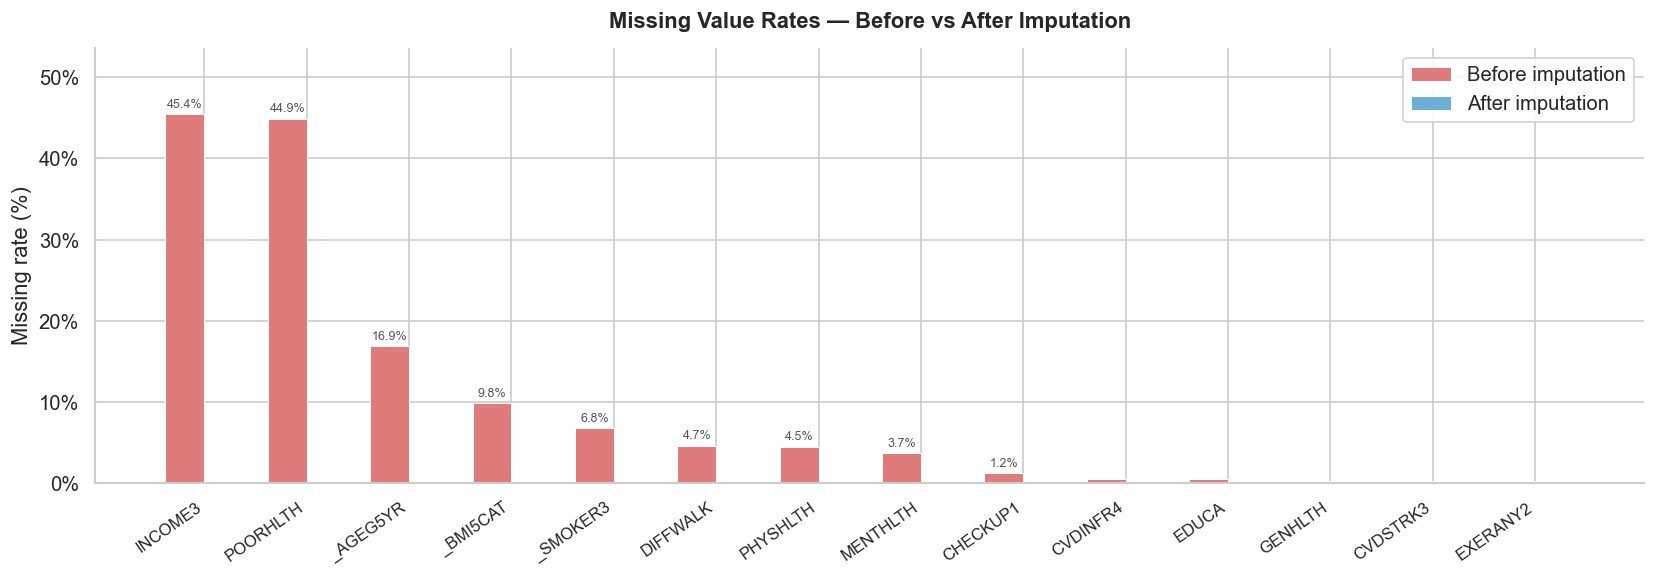

Figure saved → ..\outputs\figures\12_missing_before_after_imputation.png


In [16]:
# ── 6e. Bar chart: missing rates before vs after imputation ───────────────────
# Variables that had missing values before imputation are shown.
# All "after" bars should reach 0% — confirming successful cleaning.

plot_vars   = mb.index.tolist()
before_vals = missing_before_pct[plot_vars].values
after_vals  = missing_after_pct[plot_vars].values

x     = np.arange(len(plot_vars))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 5))

bars1 = ax.bar(x - width / 2, before_vals, width,
               label="Before imputation",
               color="#e07b7b", edgecolor="white", linewidth=0.6)
bars2 = ax.bar(x + width / 2, after_vals, width,
               label="After imputation",
               color="#6baed6", edgecolor="white", linewidth=0.6)

# Annotate before-bars only (to keep chart readable)
for bar in bars1:
    h = bar.get_height()
    if h > 0.8:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                f"{h:.1f}%", ha="center", va="bottom",
                fontsize=7.5, color="#555")

ax.set_xticks(x)
ax.set_xticklabels(plot_vars, rotation=35, ha="right", fontsize=10)
ax.set_ylabel("Missing rate (%)")
ax.set_title("Missing Value Rates — Before vs After Imputation",
             fontweight="bold", pad=12)
ax.legend(framealpha=0.85)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.set_ylim(0, max(before_vals) * 1.18)
sns.despine()
plt.tight_layout()

out_path = FIGURES_DIR / "12_missing_before_after_imputation.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {out_path}")

---
## Section 7 — Final Validation

Before saving, we verify that the cleaned dataset meets all quality criteria:

| Check | Expected |
|-------|----------|
| NaN values | 0 |
| Object dtype columns | 0 |
| Rows | ~1,240,000+ (substantially more than the original 900k due to expanded imputation) |
| Columns | 17 (16 features + 1 binary target) |
| Positive class (DIABETES=1) | ~14% |
| All key predictors retained | `GENHLTH`, `_AGEG5YR`, `DIFFWALK`, `_BMI5CAT`, `PHYSHLTH`, `INCOME3` ✅ |

In [17]:
print("═" * 60)
print("  FINAL CLEANED DATASET — VALIDATION REPORT")
print("═" * 60)

# ── Shape ─────────────────────────────────────────────────────────────────────
print(f"\n  Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── NaN check ─────────────────────────────────────────────────────────────────
total_nan  = df.isnull().sum().sum()
nan_status = "✅ PASS" if total_nan == 0 else f"❌ FAIL — {total_nan:,} NaN remaining"
print(f"  NaN values     : {total_nan}   {nan_status}")

# ── Object dtype check ────────────────────────────────────────────────────────
obj_cols     = df.select_dtypes(include="object").columns.tolist()
dtype_status = "✅ PASS — all numeric" if not obj_cols else f"⚠️  Object columns found: {obj_cols}"
print(f"  Dtypes check   : {dtype_status}")

# ── Class distribution ────────────────────────────────────────────────────────
n_pos   = (df["DIABETES"] == 1).sum()
n_neg   = (df["DIABETES"] == 0).sum()
pct_pos = n_pos / len(df) * 100
pct_neg = n_neg / len(df) * 100

print(f"\n  ── Class Distribution ─────────────────────────────────")
print(f"  DIABETES = 1 (Diabetes)    : {n_pos:>9,}  ({pct_pos:.1f}%)")
print(f"  DIABETES = 0 (No Diabetes) : {n_neg:>9,}  ({pct_neg:.1f}%)")
print(f"  Total                      : {len(df):>9,}")

# ── Dtypes ────────────────────────────────────────────────────────────────────
print(f"\n  ── Column dtypes ──────────────────────────────────────")
print(df.dtypes.to_string())

════════════════════════════════════════════════════════════
  FINAL CLEANED DATASET — VALIDATION REPORT
════════════════════════════════════════════════════════════

  Shape          : 1,252,580 rows × 17 columns
  NaN values     : 0   ✅ PASS
  Dtypes check   : ✅ PASS — all numeric

  ── Class Distribution ─────────────────────────────────
  DIABETES = 1 (Diabetes)    :   180,803  (14.4%)
  DIABETES = 0 (No Diabetes) : 1,071,777  (85.6%)
  Total                      : 1,252,580

  ── Column dtypes ──────────────────────────────────────
YEAR          int64
GENHLTH     float64
PHYSHLTH    float64
MENTHLTH    float64
POORHLTH    float64
CHECKUP1    float64
EXERANY2    float64
DIFFWALK    float64
CVDINFR4    float64
CVDSTRK3    float64
EDUCA       float64
INCOME3     float64
_SEX        float64
_AGEG5YR    float64
_BMI5CAT    float64
_SMOKER3    float64
DIABETES      int32


In [18]:
# ── Variable dictionary — all retained features ───────────────────────────────
VAR_DESC = {
    "YEAR"     : "Survey year (2022, 2023, or 2024)",
    "GENHLTH"  : "Self-rated general health (1=Excellent … 5=Poor)",
    "PHYSHLTH" : "Days physical health not good in past 30 days (0–30)",
    "MENTHLTH" : "Days mental health not good in past 30 days (0–30)",
    "POORHLTH" : "Days poor health limited activities in past 30 days (0–30)",
    "CHECKUP1" : "Time since last routine checkup (1=<1yr … 8=Never)",
    "EXERANY2" : "Physical activity in past 30 days (1=Yes, 2=No)",
    "DIFFWALK" : "Difficulty walking or climbing stairs (1=Yes, 2=No)",
    "CVDINFR4" : "History of heart attack (1=Yes, 2=No)",
    "CVDSTRK3" : "History of stroke (1=Yes, 2=No)",
    "EDUCA"    : "Highest education level (1=None … 6=College graduate)",
    "INCOME3"  : "Annual household income bracket (1=<$10k … 11=$200k+)",
    "_SEX"     : "Sex (1=Male, 2=Female)",
    "_AGEG5YR" : "Age group in 5-year intervals (1=18–24 … 13=80+)",
    "_BMI5CAT" : "BMI category (1=Underweight, 2=Normal, 3=Overweight, 4=Obese)",
    "_SMOKER3" : "Smoking status (1=Current daily … 4=Never)",
    "DIABETES" : "★ TARGET — Diabetes diagnosis (1=Yes, 0=No)",
}

print("\n  ── Retained Variables ─────────────────────────────────────────────────")
print(f"  {'Column':<12}  {'Description'}")
print("  " + "-" * 72)
for col in df.columns:
    desc = VAR_DESC.get(col, "—")
    print(f"  {col:<12}  {desc}")


  ── Retained Variables ─────────────────────────────────────────────────
  Column        Description
  ------------------------------------------------------------------------
  YEAR          Survey year (2022, 2023, or 2024)
  GENHLTH       Self-rated general health (1=Excellent … 5=Poor)
  PHYSHLTH      Days physical health not good in past 30 days (0–30)
  MENTHLTH      Days mental health not good in past 30 days (0–30)
  POORHLTH      Days poor health limited activities in past 30 days (0–30)
  CHECKUP1      Time since last routine checkup (1=<1yr … 8=Never)
  EXERANY2      Physical activity in past 30 days (1=Yes, 2=No)
  DIFFWALK      Difficulty walking or climbing stairs (1=Yes, 2=No)
  CVDINFR4      History of heart attack (1=Yes, 2=No)
  CVDSTRK3      History of stroke (1=Yes, 2=No)
  EDUCA         Highest education level (1=None … 6=College graduate)
  INCOME3       Annual household income bracket (1=<$10k … 11=$200k+)
  _SEX          Sex (1=Male, 2=Female)
  _AGEG5YR      

In [19]:
# ── Raw → Cleaned transformation summary ─────────────────────────────────────
print("\n  ── Raw → Cleaned Summary ───────────────────────────────────────────────")
print(f"  Raw shape     : 1,336,125 rows × 23 columns")
print(f"  Clean shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print("  Columns removed (7) : BPHIGH6, _CHOLCH3, PREDIAB2, SEXVAR, _STATE, _RACE, DIABETE4")
print("  Columns added  (1)  : DIABETES  (binary 0/1 target)")
print()
print("  Row removals:")
print("    • DIABETE4 codes 2/4/7/9 excluded (gestational, pre-diabetes, don't know/refused)")
print("    • Row-drop applied only to <3% missing vars after imputation")
print()
print("  Imputed variables (median) : INCOME3, POORHLTH, _AGEG5YR, _BMI5CAT, _SMOKER3, PHYSHLTH, MENTHLTH")
print("  Imputed variables (mode)   : DIFFWALK")
print()
print("  ✅ Dataset is clean, complete, and ready for Phase 3 — Feature Engineering.")


  ── Raw → Cleaned Summary ───────────────────────────────────────────────
  Raw shape     : 1,336,125 rows × 23 columns
  Clean shape   : 1,252,580 rows × 17 columns

  Columns removed (7) : BPHIGH6, _CHOLCH3, PREDIAB2, SEXVAR, _STATE, _RACE, DIABETE4
  Columns added  (1)  : DIABETES  (binary 0/1 target)

  Row removals:
    • DIABETE4 codes 2/4/7/9 excluded (gestational, pre-diabetes, don't know/refused)
    • Row-drop applied only to <3% missing vars after imputation

  Imputed variables (median) : INCOME3, POORHLTH, _AGEG5YR, _BMI5CAT, _SMOKER3, PHYSHLTH, MENTHLTH
  Imputed variables (mode)   : DIFFWALK

  ✅ Dataset is clean, complete, and ready for Phase 3 — Feature Engineering.


---
## Section 8 — Save Output

The cleaned dataset is saved to `data/processed/brfss_cleaned.csv`.  
This file is the **sole input for Phase 3 — Feature Engineering**, which will:

- Evaluate and handle multicollinearity between `PHYSHLTH` and `POORHLTH` (r = 0.70) — consider dropping one or creating a composite feature
- Assess feature importance and consider interaction or polynomial features
- Address class imbalance (~14% positive class) via SMOTE or `class_weight='balanced'`
- Cast ordinal variables from float64 to integer types before encoding
- Prepare the final feature matrix `X` and target vector `y` for modelling

In [20]:
df.to_csv(CLEAN_FILE, index=False)

file_size_mb = CLEAN_FILE.stat().st_size / (1024 ** 2)

print("✅ Cleaned dataset saved successfully.")
print(f"   Path   : {CLEAN_FILE.resolve()}")
print(f"   Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Size   : {file_size_mb:.1f} MB")
print()
print("   Phase 3 (Feature Engineering) receives:")
print(f"   • {df.shape[1] - 1} features + 1 binary target (DIABETES)")
print(f"   • Zero missing values")
print(f"   • {(df['DIABETES']==1).sum():,} positive class ({(df['DIABETES']==1).mean()*100:.1f}%) "
      f"/ {(df['DIABETES']==0).sum():,} negative class ({(df['DIABETES']==0).mean()*100:.1f}%)")
print()
print("   Known issues to address in Phase 3:")
print("   • PHYSHLTH / POORHLTH multicollinearity (r=0.70) — evaluate VIF; consider dropping one")
print("   • Class imbalance (~14% positive) — SMOTE or class_weight='balanced'")
print("   • Ordinal vars stored as float64 — cast to int before encoding if needed")

✅ Cleaned dataset saved successfully.
   Path   : D:\Users\kotae\Documents\Portfolio\project\Project 2\diabetes-risk-prediction\data\processed\brfss_cleaned.csv
   Shape  : 1,252,580 rows × 17 columns
   Size   : 82.4 MB

   Phase 3 (Feature Engineering) receives:
   • 16 features + 1 binary target (DIABETES)
   • Zero missing values
   • 180,803 positive class (14.4%) / 1,071,777 negative class (85.6%)

   Known issues to address in Phase 3:
   • PHYSHLTH / POORHLTH multicollinearity (r=0.70) — evaluate VIF; consider dropping one
   • Class imbalance (~14% positive) — SMOTE or class_weight='balanced'
   • Ordinal vars stored as float64 — cast to int before encoding if needed
